In [4]:

# Cell 1: Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import glob
from PIL import Image
import cv2

2025-04-13 17:55:21.798840: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-13 17:55:21.882133: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744547121.931655  379691 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744547121.938828  379691 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744547121.973917  379691 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.8/644.8 MB 2.8 MB/s eta 0:00:0000:0100:03
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 KB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 6.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 7.2 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 6.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 KB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 KB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.8/82.8 KB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 KB 2.2 MB/s 

In [29]:
# Cell 2: Define parameters and directories
# Define the path to your image data
data_dir = '/mnt/d/Codes/ml-zone/projects/chess-board-next-move-predictor/data/peices'
# Define the piece types
piece_types = ['pawn', 'rook', 'knight', 'bishop', 'queen', 'king']
# Define image size
img_height, img_width = 128, 128

In [30]:
# Cell 3: Create function to load and preprocess images
def load_and_preprocess_data(data_dir, piece_types, img_height, img_width):
    images = []
    labels = []
    
    # Print directory to check if it exists
    print(f"Looking for data in: {os.path.abspath(data_dir)}")
    
    for idx, piece_type in enumerate(piece_types):
        piece_dir = os.path.join(data_dir, piece_type)
        
        # Check if directory exists
        if not os.path.exists(piece_dir):
            print(f"Warning: Directory {piece_dir} does not exist!")
            continue
            
        # Get all image files with various extensions
        image_files = []
        for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.tiff']:
            image_files.extend(glob.glob(os.path.join(piece_dir, ext)))
            
        print(f"Found {len(image_files)} images for {piece_type}")
        
        if len(image_files) == 0:
            print(f"Warning: No images found in {piece_dir}")
            # List all files in the directory to debug
            print(f"Files in directory: {os.listdir(piece_dir) if os.path.exists(piece_dir) else 'Directory not found'}")
            continue
            
        for img_path in image_files:
            try:
                # Load image
                img = Image.open(img_path)
                # Convert to grayscale (single channel)
                img = img.convert('L')
                # Resize image
                img = img.resize((img_width, img_height))
                # Convert to numpy array
                img_array = np.array(img)
                # Normalize pixel values to range [0, 1]
                img_array = img_array / 255.0
                
                # Append to lists
                images.append(img_array)
                labels.append(idx)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
    
    # Check if we found any images
    if len(images) == 0:
        raise ValueError("No images were found or successfully processed!")
        
    # Convert lists to numpy arrays
    images = np.array(images)
    labels = np.array(labels)
    
    print(f"Total images processed: {len(images)}")
    print(f"Labels distribution: {np.bincount(labels)}")
    
    # Reshape images to add channel dimension (single channel)
    images = images.reshape(images.shape[0], img_height, img_width, 1)
    
    return images, labels

In [31]:

# Cell 4: Load and preprocess data
X, y = load_and_preprocess_data(data_dir, piece_types, img_height, img_width)

Looking for data in: /mnt/d/Codes/ml-zone/projects/chess-board-next-move-predictor/data/peices
Found 128 images for pawn
Found 32 images for rook
Found 32 images for knight
Found 32 images for bishop
Found 16 images for queen
Found 16 images for king
Total images processed: 256
Labels distribution: [128  32  32  32  16  16]


In [32]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5])

In [33]:
# Cell 5: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
# Cell 6: Convert labels to one-hot encoding
y_train_categorical = to_categorical(y_train, num_classes=len(piece_types))
y_test_categorical = to_categorical(y_test, num_classes=len(piece_types))

In [36]:
y_train_categorical

array([[0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.]])

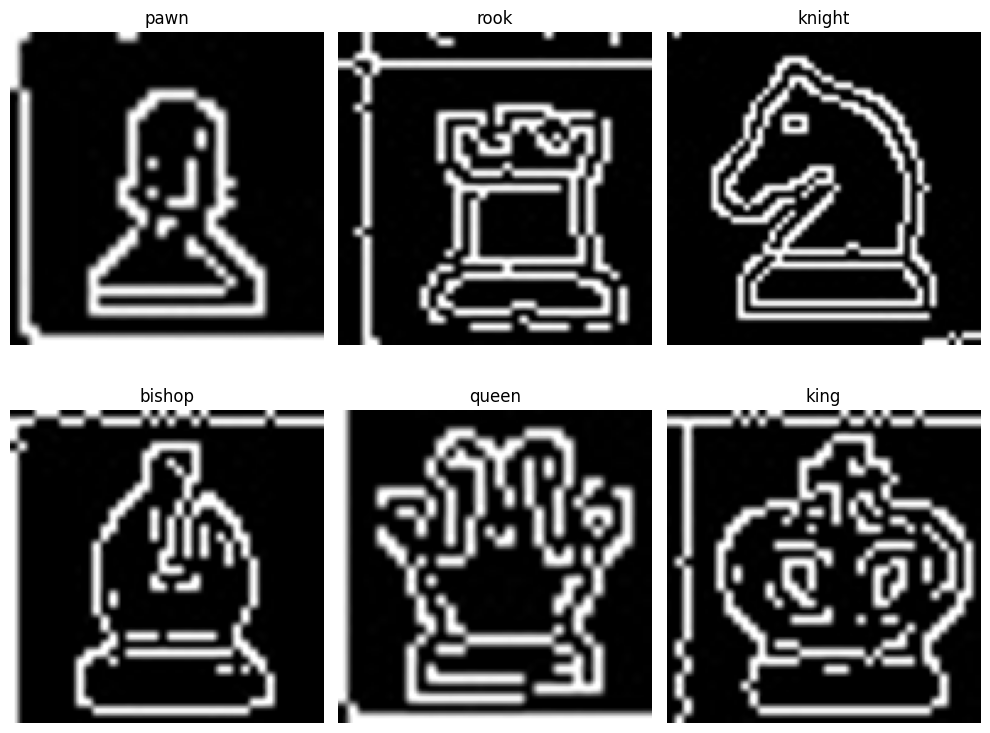

In [35]:
# Cell 7: Data visualization - display sample images
plt.figure(figsize=(10, 8))
for i in range(6):
    class_indices = np.where(y == i)[0]
    sample_idx = np.random.choice(class_indices)
    plt.subplot(2, 3, i+1)
    plt.imshow(X[sample_idx].reshape(img_height, img_width), cmap='gray')
    plt.title(piece_types[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [37]:
# Cell 8: Check shapes of training and testing data
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train_categorical.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Testing labels shape: {y_test_categorical.shape}")

Training data shape: (204, 128, 128, 1)
Training labels shape: (204, 6)
Testing data shape: (52, 128, 128, 1)
Testing labels shape: (52, 6)


In [38]:
# Cell 9: Data augmentation (if needed)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [39]:
# Cell 10: Define a simple CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def create_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 1)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(len(piece_types), activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [40]:
# Cell 11: Create and summarize the model
model = create_model()
model.summary()

/home/mdirfan-code/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-04-13 18:08:39.681380: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,838 (12.61 MB)

 Trainable params: 3,304,838 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:

# Cell 12: Prepare for training
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [42]:

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('chess_piece_classifier.h5', monitor='val_accuracy', save_best_only=True)


In [43]:
# Cell 13: Train the model
batch_size = 32
epochs = 25

history = model.fit(
    datagen.flow(X_train, y_train_categorical, batch_size=batch_size),
    epochs=epochs,
    validation_data=(X_test, y_test_categorical),
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/25


/home/mdirfan-code/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.3859 - loss: 1.6769

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 288ms/step - accuracy: 0.3952 - loss: 1.6626 - val_accuracy: 0.4615 - val_loss: 1.3504
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.5588 - loss: 1.2723

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 285ms/step - accuracy: 0.5558 - loss: 1.2698 - val_accuracy: 0.6346 - val_loss: 0.9245
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.6583 - loss: 0.9440

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - accuracy: 0.6551 - loss: 0.9505 - val_accuracy: 0.6731 - val_loss: 0.7477
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6052 - loss: 1.0193

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.6050 - loss: 1.0194 - val_accuracy: 0.7692 - val_loss: 0.7703
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.6545 - loss: 0.8100

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.6597 - loss: 0.8069 - val_accuracy: 0.9231 - val_loss: 0.4734
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.6852 - loss: 0.7444 - val_accuracy: 0.8846 - val_loss: 0.3197
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - accuracy: 0.7585 - loss: 0.6294 - val_accuracy: 0.9038 - val_loss: 0.2694
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.7878 - loss: 0.5538

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step - accuracy: 0.7923 - loss: 0.5474 - val_accuracy: 1.0000 - val_loss: 0.1194
Epoch 9/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.8365 - loss: 0.4470 - val_accuracy: 1.0000 - val_loss: 0.0678
Epoch 10/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.8483 - loss: 0.4086 - val_accuracy: 1.0000 - val_loss: 0.0489
Epoch 11/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.8880 - loss: 0.3203 - val_accuracy: 1.0000 - val_loss: 0.0256
Epoch 12/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.8732 - loss: 0.3432 - val_accuracy: 1.0000 - val_loss: 0.0342
Epoch 13/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.8771 - loss: 0.3820 - val_accuracy: 1.0000 - val_loss: 0.0420
Epoch 14/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.8952 - loss: 0.3065 - val_accuracy: 1.0000 - val_loss: 0.0203
Epoch 15/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.9066 - loss: 0.2489 - val_accuracy: 1.0000 - val_loss: 0.01

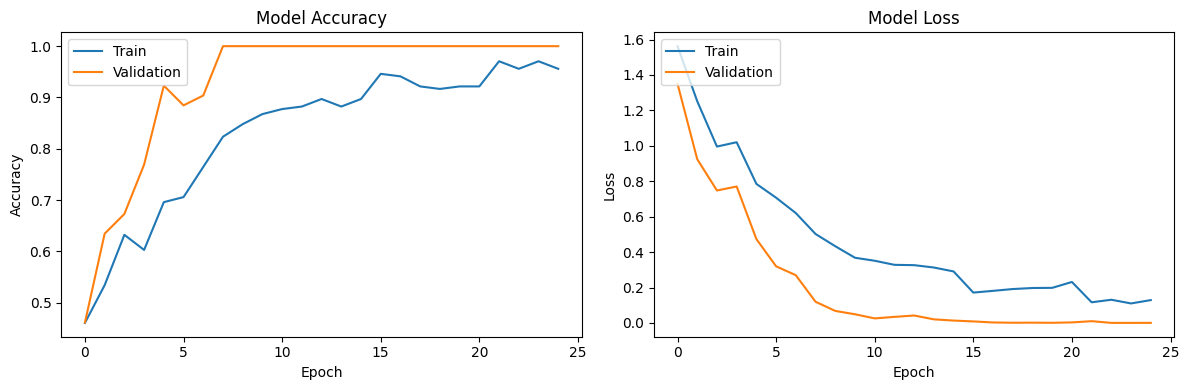

In [44]:
# Cell 14: Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [45]:
# Cell 15: Evaluate the model
evaluation = model.evaluate(X_test, y_test_categorical)
print(f"Test Loss: {evaluation[0]}")
print(f"Test Accuracy: {evaluation[1]}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 2.6682e-04
Test Loss: 0.00028776732506230474
Test Accuracy: 1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


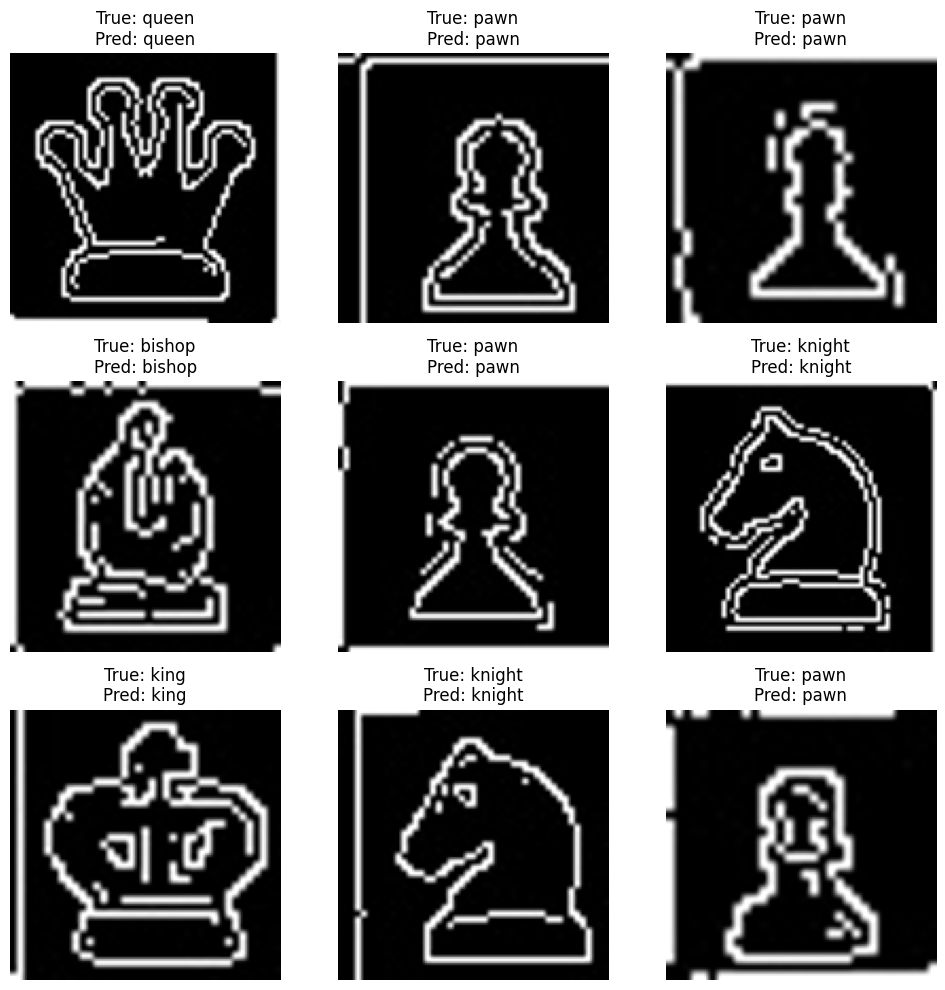

In [46]:
# Cell 16: Predict and visualize results
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# Display some test predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test[i].reshape(img_height, img_width), cmap='gray')
    plt.title(f"True: {piece_types[y_true_classes[i]]}\nPred: {piece_types[y_pred_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

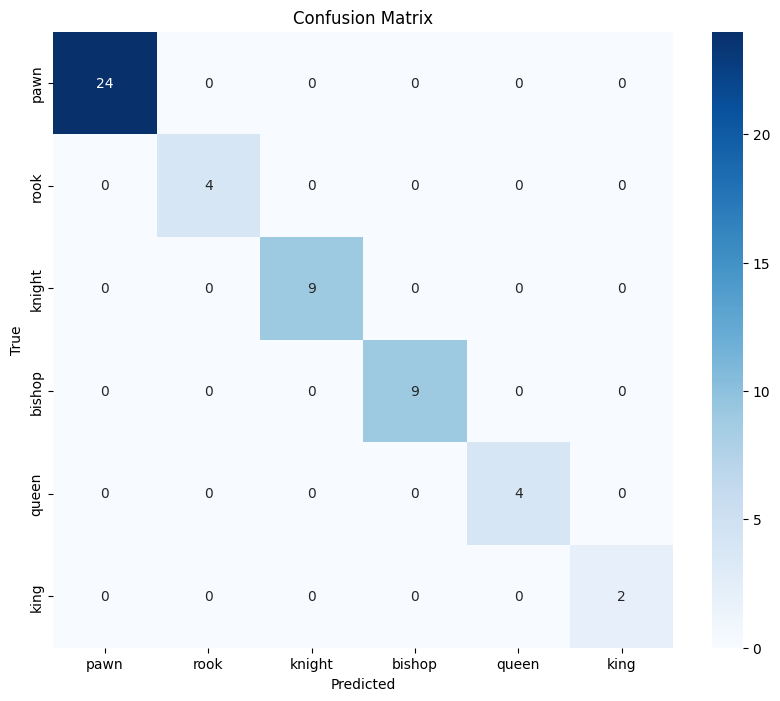

In [47]:
# Cell 17: Create a confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=piece_types, yticklabels=piece_types)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [48]:
# Cell 18: Display classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=piece_types)
print(report)

              precision    recall  f1-score   support

        pawn       1.00      1.00      1.00        24
        rook       1.00      1.00      1.00         4
      knight       1.00      1.00      1.00         9
      bishop       1.00      1.00      1.00         9
       queen       1.00      1.00      1.00         4
        king       1.00      1.00      1.00         2

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted avg       1.00      1.00      1.00        52



In [49]:
# Cell 19: Save the model
model.save('chess_piece_classification_model.h5')
print("Model saved successfully!")


Model saved successfully!


In [ ]:
# Cell 20: Function to make predictions on new images
def predict_piece(image_path, model):
    # Load and preprocess the image
    img = Image.open(image_path).convert('L')
    
    img = img.resize((img_width, img_height))
    img_array = np.array(img) / 255.0
    img_array = img_array.reshape(1, img_height, img_width, 1)
    
    # Predict
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    
    print(f"Predicted piece: {piece_types[predicted_class]} (Confidence: {confidence:.2f}%)")
    
    # Display the image
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {piece_types[predicted_class]}")
    plt.axis('off')
    plt.show()
    
    return piece_types[predicted_class], confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted piece: rook (Confidence: 99.96%)


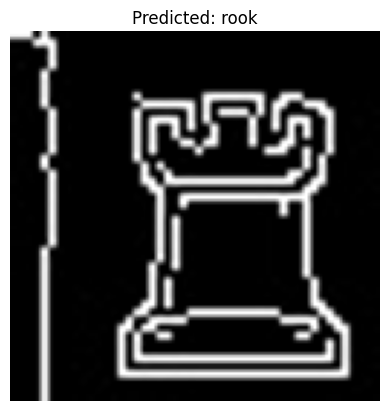

('rook', 99.96492862701416)

In [52]:
predict_piece("/mnt/d/Codes/ml-zone/projects/chess-board-next-move-predictor/data/peices/rook/img_b_rook_17.jpg",model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted piece: queen (Confidence: 99.96%)


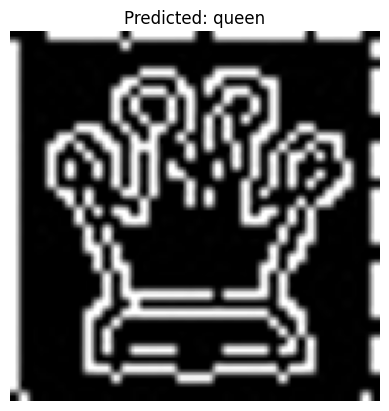

('queen', 99.96391534805298)

In [53]:
predict_piece("/mnt/d/Codes/ml-zone/projects/chess-board-next-move-predictor/data/peices/queen/img_b_queen_83.jpg",model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted piece: bishop (Confidence: 99.88%)


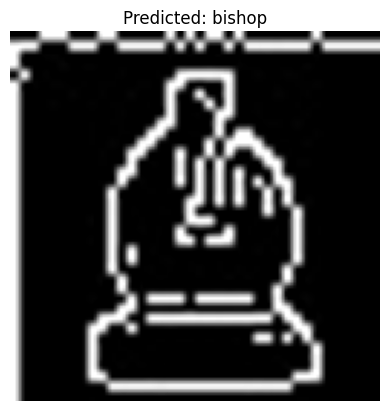

('bishop', 99.88456964492798)

In [56]:
predict_piece("/mnt/d/Codes/ml-zone/projects/chess-board-next-move-predictor/data/peices/bishop/img_b_bishop_62.jpg",model)